# Kubernetes Incident-Agent Evaluation Report

This notebook produces a paper-ready report for the TeaStore and Online Boutique evaluation batches. Grading statistics use only runs whose raw evaluation metadata is `completed`. Execution failures are reported separately.

The score-based success threshold is **0.8**. A scenario-stage succeeds when at least one succeeded job in that completed run reaches the threshold. The run/scenario is the unit of analysis, so scenarios producing more jobs do not receive more weight.

## Metric definitions and formulas

### Notation and analysis population

Let `C` be the set of raw run folders whose `metadata.json` has `status = completed`; `N = |C|`. All grading rates and score summaries in this notebook use only `C`. A missing-metadata or failed execution is shown in failure accounting but is not included in grading denominators. Let `J_R(r)` and `J_M(r)` be the RCA and remediation jobs for completed run `r`. Let `J*_R(r)` and `J*_M(r)` retain only jobs with `status = succeeded` and a numeric overall score. The indicator `I(condition)` is 1 when the condition is true and 0 otherwise.

### Execution metrics

- **Status count:** `n_status = sum over all run folders of I(execution_status = status)`.
- **Total discovered runs:** `N_discovered = completed + failed + missing_metadata + any other statuses`.
- **Completion rate:** `100 * completed / N_discovered`.
- **Baseline request failure ratio:** `100 * failed_requests / total_requests`. A baseline passes only when this ratio does not exceed the configured maximum and the other baseline-health requirements pass.

### Score-based scenario metrics at threshold T = 0.8

- **Best RCA score for run r:** `B_R(r) = max(score(j) for j in J*_R(r))`; missing when no succeeded scored RCA exists.
- **Best remediation score for run r:** `B_M(r) = max(score(j) for j in J*_M(r))`; missing when no succeeded scored remediation exists.
- **RCA score success:** `S_R(r) = I(B_R(r) >= T)`. A completed run with no qualifying RCA has `S_R(r) = 0`.
- **Remediation score success:** `S_M(r) = I(B_M(r) >= T)`. A completed run with no qualifying remediation has `S_M(r) = 0`.
- **Joint score success:** `S_J(r) = S_R(r) * S_M(r)`.
- **RCA successes:** `sum over r in C of S_R(r)`.
- **Remediation successes:** `sum over r in C of S_M(r)`.
- **Joint successes:** `sum over r in C of S_J(r)`.
- **RCA-SSR:** `100 * sum(S_R(r)) / N`.
- **Remediation-SSR:** `100 * sum(S_M(r)) / N`. This is score-only and is not the strict recovery rate.
- **Joint score SSR:** `100 * sum(S_J(r)) / N`.
- **Application or fault-family SSR:** apply the same numerator and denominator inside the selected subgroup.

### Strict semantic and recovery metrics

- **Aligned RCA success for run r:** `A_R(r) = I(any succeeded RCA has alignment = aligned)`.
- **Aligned RCA rate:** `100 * sum(A_R(r)) / N`.
- **Metric recovery success for run r:** `G(r) = I(any succeeded remediation has metric_outcome = good)`.
- **Strict recovery success for run r:** `R(r) = I(any succeeded remediation has final_grade = good)`. A final `good` grade requires semantic alignment and a good metric outcome under the grader policy.
- **Strict recovery rate:** `100 * sum(R(r)) / N`.

### Wilson 95% confidence interval for a rate

For `k` successes in `n` runs, `p = k/n` and `z = 1.959964`. The displayed lower and upper bounds are:

`center = (p + z^2/(2n)) / (1 + z^2/n)`

`margin = z * sqrt(p(1-p)/n + z^2/(4n^2)) / (1 + z^2/n)`

`95% CI = 100 * [max(0, center-margin), min(1, center+margin)]`.

### Rubric-score formulas

Each criterion score is one of `{0, 0.25, 0.5, 0.75, 1}`.

- **RCA overall score:** `0.30*RC + 0.25*CR + 0.20*EG + 0.15*LA + 0.10*DC`, where RC is root-cause correctness, CR causal reasoning, EG evidence grounding, LA localization accuracy, and DC diagnostic completeness.
- **Remediation rubric score:** `0.30*RC + 0.20*TF + 0.20*RS + 0.15*EA + 0.15*CM`, where RC is remediation correctness, TF technical feasibility, RS risk and safety, EA evidence alignment, and CM remediation completeness.
- **Penalized remediation overall score:** `max(0, remediation_rubric_score - penalty_total)`.
- **Mean criterion score:** `sum(valid criterion scores) / number of valid criterion scores`.
- **Total penalty:** `sum(applied scenario-penalty weights for the remediation)`.

### Job production and distribution metrics

- **RCA jobs / remediation jobs per run:** count of captured rows of that kind for the run.
- **Job status count:** `sum I(job_status = selected status)` within the displayed application and job kind.
- **Alignment count:** `sum I(alignment = selected verdict)` within the displayed application and job kind.
- **Outputs:** number of succeeded jobs with a numeric overall score.
- **Mean score:** `sum(x_i) / n`.
- **Median score:** middle ordered value, or the mean of the two middle values when `n` is even.
- **Sample standard deviation:** `sqrt(sum((x_i - mean)^2) / (n-1))`.
- **Minimum / maximum:** smallest / largest valid score.
- **Q1 / Q3:** pandas linear-interpolated 25th / 75th percentiles of valid scores.
- **Median best RCA / remediation score:** median of `B_R(r)` / `B_M(r)` among non-missing run scores in the subgroup.

### Metric-recovery and safety metrics

For core metric family `m` (response-time P95 or HTTP 5xx rate):

- **Before median:** median of observations in the five-minute pre-remediation window.
- **After median:** median of observations in the five-minute post-remediation window.
- **Relative change:** `(after_median - before_median) / before_median`; undefined when the before median is zero.
- **Improved:** relative change is at most `-0.15`; **worsened:** at least `+0.15`; otherwise **stable**.
- **Good remediation metric outcome:** at least one evaluable core family improved and no core family worsened. Counts in the metric-outcome table are `sum I(metric_outcome = category)`.
- **Final-grade count:** `sum I(final_grade = category)`.
- **Succeeded remediations:** count of remediation jobs with `status = succeeded`.
- **Penalized remediations:** `sum I(penalty_total > 0)` among succeeded remediations.
- **Penalized percent:** `100 * penalized_remediations / succeeded_remediations`.
- **Mean penalty:** `sum(penalty_total) / succeeded_remediations`.
- **Non-succeeded job-state count:** `sum I(job_status = queued, running, needs_review, or another non-succeeded state)`.

All bar-chart rates are the corresponding formulas above. Histogram heights are simple counts of succeeded scored jobs falling in each 0.1-wide score bin.

In [9]:
from pathlib import Path
from statistics import NormalDist
import json, os, tempfile

ROOT = Path.cwd().resolve()
if not (ROOT / 'grades').is_dir():
    ROOT = ROOT.parent
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'evaluation-report-mpl'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

THRESHOLD = 0.8
DATASETS = {'TeaStore': 'teastore-1', 'Online Boutique': 'online-boutique-1'}
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 100)

def fault_family(name):
    name = str(name)
    for token, label in [('node-delay','Node delay'), ('node-loss','Node loss'),
                         ('node-cpu','Node CPU'), ('node-memory','Node memory'),
                         ('capacity-loss','Pod capacity loss'), ('bandwidth','Pod bandwidth'),
                         ('cpu-headroom','Pod CPU headroom'), ('memory','Pod memory'), ('cpu','Pod CPU')]:
        if token in name:
            return label
    return 'Other'

def wilson(successes, total, confidence=0.95):
    if total == 0:
        return (np.nan, np.nan)
    z = NormalDist().inv_cdf(1 - (1-confidence)/2)
    p = successes / total
    den = 1 + z*z/total
    center = (p + z*z/(2*total))/den
    margin = z*np.sqrt(p*(1-p)/total + z*z/(4*total*total))/den
    return max(0, center-margin), min(1, center+margin)

def failure_detail(meta):
    failed = [p for p in meta.get('phases', []) if p.get('status') != 'completed']
    if not failed:
        return ''
    phase = failed[0]; details = phase.get('details') or {}
    if phase.get('name') == 'baseline':
        h = details.get('health') or {}
        return f"baseline failure ratio {100*h.get('failure_ratio', 0):.2f}% (limit {100*h.get('maximum_failure_ratio', 0):.2f}%)"
    if phase.get('name') == 'chaos':
        return str((details.get('step') or {}).get('error') or 'chaos phase failed')
    cmd = details.get('command') or {}
    errors = cmd.get('errors') or []
    if errors:
        return '; '.join(errors)
    return str(cmd.get('failed_command') or f"{phase.get('name')} failed")

execution_rows, summary_frames, rca_frames, remediation_frames = [], [], [], []
for application, dataset in DATASETS.items():
    result_root = ROOT / 'results' / dataset
    for run_dir in sorted(p for p in result_root.iterdir() if p.is_dir()):
        path = run_dir / 'metadata.json'
        if path.exists():
            meta = json.loads(path.read_text())
            execution_rows.append({'application': application, 'run': run_dir.name,
                'scenario': (meta.get('scenario') or {}).get('name'), 'execution_status': meta.get('status'),
                'failed_phase': next((p.get('name') for p in meta.get('phases', []) if p.get('status') != 'completed'), ''),
                'failure_detail': failure_detail(meta)})
        else:
            execution_rows.append({'application': application, 'run': run_dir.name, 'scenario': None,
                'execution_status': 'missing_metadata', 'failed_phase': 'unknown',
                'failure_detail': 'metadata.json was not produced'})
    for filename, target in [('summary.csv', summary_frames), ('rca_rubric_score.csv', rca_frames),
                             ('remediation_rubric_score.csv', remediation_frames)]:
        frame = pd.read_csv(ROOT / 'grades' / dataset / filename)
        frame.insert(0, 'application', application)
        target.append(frame)

execution = pd.DataFrame(execution_rows)
summary_all = pd.concat(summary_frames, ignore_index=True)
rca_all = pd.concat(rca_frames, ignore_index=True)
remediation_all = pd.concat(remediation_frames, ignore_index=True)
completed = set(execution.loc[execution.execution_status.eq('completed'), 'run'])
summary = summary_all[summary_all.run.isin(completed)].copy()
rca = rca_all[rca_all.run.isin(completed)].copy()
remediation = remediation_all[remediation_all.run.isin(completed)].copy()
for frame in (summary, rca, remediation):
    frame['overall_score'] = pd.to_numeric(frame['overall_score'], errors='coerce')

run_rows = []
for _, e in execution[execution.execution_status.eq('completed')].iterrows():
    jobs = summary[summary.run.eq(e.run)]
    r = jobs[(jobs.kind.eq('rca')) & jobs.status.eq('succeeded')]
    m = jobs[(jobs.kind.eq('remediation')) & jobs.status.eq('succeeded')]
    r_scores, m_scores = r.overall_score.dropna(), m.overall_score.dropna()
    run_rows.append({'application': e.application, 'run': e.run,
        'scenario': e.scenario or (jobs.scenario.iloc[0] if len(jobs) else ''),
        'fault_family': fault_family(e.scenario or (jobs.scenario.iloc[0] if len(jobs) else '')),
        'rca_jobs': len(jobs[jobs.kind.eq('rca')]), 'remediation_jobs': len(jobs[jobs.kind.eq('remediation')]),
        'best_rca_score': r_scores.max() if len(r_scores) else np.nan,
        'best_remediation_score': m_scores.max() if len(m_scores) else np.nan,
        'rca_score_success': bool((r_scores >= THRESHOLD).any()),
        'remediation_score_success': bool((m_scores >= THRESHOLD).any()),
        'rca_aligned_success': bool((r.alignment == 'aligned').any()),
        'strict_recovery_success': bool((m.final_grade == 'good').any()),
        'metric_recovery_success': bool((m.metric_outcome == 'good').any())})
runs = pd.DataFrame(run_rows)
runs['joint_score_success'] = runs.rca_score_success & runs.remediation_score_success
print(f'Loaded {len(execution)} run folders; {len(runs)} completed runs are used for grading analysis.')

Loaded 46 run folders; 35 completed runs are used for grading analysis.


## 1. Execution coverage and failed runs

In [10]:
execution_counts = execution.groupby(['application','execution_status']).size().unstack(fill_value=0)
execution_counts['total'] = execution_counts.sum(axis=1)
execution_counts['completion_rate_percent'] = 100 * execution_counts.get('completed', 0) / execution_counts.total
display(execution_counts.reset_index().round(1))
display(Markdown('### Failed or incomplete executions'))
display(execution.loc[~execution.execution_status.eq('completed'),
    ['application','run','execution_status','failed_phase','failure_detail']].reset_index(drop=True))

execution_status,application,completed,failed,missing_metadata,total,completion_rate_percent
0,Online Boutique,21,2,0,23,91.3
1,TeaStore,14,8,1,23,60.9


### Failed or incomplete executions

,application,run,execution_status,failed_phase,failure_detail
0,TeaStore,20260909-042159-01-node-delay-worker-3-agents-constant,failed,application_reset,application pod is not Ready: teastore-persistence-cffd46c87-fdsxv; pod teastore-persistence-cff...
1,TeaStore,20260909-064722-03-node-delay-worker-4-agents-constant,missing_metadata,unknown,metadata.json was not produced
2,TeaStore,20260909-113049-06-node-loss-worker-3-agents-constant,failed,baseline,baseline failure ratio 55.30% (limit 1.00%)
3,TeaStore,20260910-001843-12-node-cpu-worker-2-agents-constant,failed,baseline,baseline failure ratio 54.80% (limit 1.00%)
4,TeaStore,20260910-012737-13-node-memory-worker-3-agents-constant,failed,chaos,failed to apply Schedule node-memory-worker-3
5,TeaStore,20260910-131118-18-pod-auth-memory-all-agents-constant,failed,application_reset,application pod is not Ready: teastore-auth-5cf655bdf6-ngdg7
6,TeaStore,20260910-131651-19-pod-recommender-bandwidth-all-agents-constant,failed,baseline,baseline failure ratio 55.71% (limit 1.00%)
7,TeaStore,20260910-190404-22-pod-persistence-cpu-headroom-all-agents-constant,failed,baseline,baseline failure ratio 3.55% (limit 1.00%)
8,TeaStore,20260910-201221-23-pod-image-cpu-headroom-all-agents-constant,failed,baseline,baseline failure ratio 60.07% (limit 1.00%)
9,Online Boutique,20260903-192357-13-node-memory-worker-3-agents-constant,failed,chaos,failed to apply Schedule node-memory-worker-3


## 2. Headline scenario success rates

RCA-SSR and Remediation-SSR below are score-based at the predeclared threshold of 0.8. Strict RCA success requires an aligned RCA. Strict recovery additionally uses the grader's final `good` classification, which incorporates semantic alignment and metric recovery.

In [3]:
def headline(group, application):
    n = len(group); row = {'Application': application, 'Completed': n}
    for column, label in [('rca_score_success','RCA-SSR'), ('remediation_score_success','Remediation-SSR'),
                          ('joint_score_success','Joint score SSR'), ('rca_aligned_success','Aligned RCA rate'),
                          ('strict_recovery_success','Strict recovery rate')]:
        k = int(group[column].sum()); lo, hi = wilson(k, n)
        row[f'{label} successes'] = k
        row[label] = f'{100*k/n:.1f}% ({k}/{n})'
        row[f'{label} 95% CI'] = f'{100*lo:.1f}–{100*hi:.1f}%'
    return row
headline_rows = [headline(g, app) for app, g in runs.groupby('application')]
headline_rows.append(headline(runs, 'Combined'))
headline_df = pd.DataFrame(headline_rows)
display(headline_df[['Application','Completed','RCA-SSR successes','RCA-SSR','RCA-SSR 95% CI',
    'Remediation-SSR successes','Remediation-SSR','Remediation-SSR 95% CI','Joint score SSR',
    'Aligned RCA rate','Strict recovery rate']])

,Application,Completed,RCA-SSR successes,RCA-SSR,RCA-SSR 95% CI,Remediation-SSR successes,Remediation-SSR,Remediation-SSR 95% CI,Joint score SSR,Aligned RCA rate,Strict recovery rate
0,Online Boutique,21,16,76.2% (16/21),54.9–89.4%,9,42.9% (9/21),24.5–63.5%,42.9% (9/21),76.2% (16/21),14.3% (3/21)
1,TeaStore,14,9,64.3% (9/14),38.8–83.7%,4,28.6% (4/14),11.7–54.6%,28.6% (4/14),64.3% (9/14),14.3% (2/14)
2,Combined,35,25,71.4% (25/35),54.9–83.7%,13,37.1% (13/35),23.2–53.7%,37.1% (13/35),71.4% (25/35),14.3% (5/35)


## 3. Successful runs at score threshold 0.8

In [4]:
successful = runs[runs.joint_score_success][['application','run','scenario','fault_family',
    'best_rca_score','best_remediation_score','strict_recovery_success']].copy()
display(successful.sort_values(['application','run']).reset_index(drop=True).round(4))
print(f'Joint score successes: {len(successful)}/{len(runs)} ({100*len(successful)/len(runs):.1f}%).')

,application,run,scenario,fault_family,best_rca_score,best_remediation_score,strict_recovery_success
0,Online Boutique,20260902-122717-01-node-delay-worker-3-agents-constant,real-node-delay-worker-3-one-hour,Node delay,1.0,1.0000,False
1,Online Boutique,20260902-144605-02-node-delay-worker-2-agents-constant,real-node-delay-worker-2-one-hour,Node delay,1.0,0.9625,False
2,Online Boutique,20260902-170445-03-node-delay-worker-5-agents-constant,real-node-delay-worker-5-one-hour,Node delay,1.0,1.0000,True
3,Online Boutique,20260902-214037-05-node-loss-worker-2-agents-constant,real-node-loss-worker-2-one-hour,Node loss,1.0,1.0000,False
4,Online Boutique,20260902-235730-06-node-loss-worker-3-agents-constant,real-node-loss-worker-3-one-hour,Node loss,1.0,1.0000,False
5,Online Boutique,20260903-075322-08-pod-checkoutservice-cpu-all-agents-constant,real-pod-checkoutservice-cpu-all-one-hour,Pod CPU,1.0,0.9625,True
6,Online Boutique,20260903-101351-09-pod-recommendationservice-cpu-all-agents-constant,real-pod-recommendationservice-cpu-all-one-hour,Pod CPU,1.0,0.9625,True
7,Online Boutique,20260903-203117-14-pod-adservice-memory-all-agents-constant,real-pod-adservice-memory-all-one-hour,Pod memory,1.0,0.8875,False
8,Online Boutique,20260908-062512-18-pod-currencyservice-memory-all-agents-constant,real-pod-currencyservice-memory-all-one-hour,Pod memory,1.0,1.0000,False
9,TeaStore,20260909-042651-02-node-delay-worker-2-agents-constant,teastore-node-delay-worker-2-one-hour,Node delay,1.0,1.0000,True


Joint score successes: 13/35 (37.1%).


## 4. Job production, completion, alignment, and score quality

In [5]:
display(pd.crosstab([summary.application, summary.kind], summary.status, margins=True))
display(Markdown('### Alignment verdicts'))
display(pd.crosstab([summary.application, summary.kind], summary.alignment, margins=True))
scored = summary[summary.status.eq('succeeded') & summary.overall_score.notna()]
score_quality = scored.groupby(['application','kind']).overall_score.agg(
    outputs='count', mean='mean', median='median', std='std', minimum='min', q1=lambda x:x.quantile(.25),
    q3=lambda x:x.quantile(.75), maximum='max').reset_index()
display(Markdown('### Job-level score distributions (secondary evidence; scenarios remain the experimental unit)'))
display(score_quality.round(4))
display(Markdown('### Mean rubric dimensions'))
rca_dims = ['root_cause_correctness','causal_reasoning_quality','evidence_grounding','localization_accuracy','diagnostic_completeness']
rem_dims = ['remediation_correctness','technical_feasibility','risk_and_safety','evidence_alignment','remediation_completeness','penalty_total']
display(rca[rca.status.eq('succeeded')].groupby('application')[rca_dims].mean().round(4))
display(remediation[remediation.status.eq('succeeded')].groupby('application')[rem_dims].mean().round(4))

status                       needs_review  queued  running  succeeded  All
application     kind                                                      
Online Boutique rca                     0       0        9        162  171
                remediation            15       0        1        103  119
TeaStore        rca                     0       0        9        144  153
                remediation             9       1        2        128  140
All                                    24       1       21        537  583

### Alignment verdicts

alignment                    aligned  not_aligned  not_evaluable  All
application     kind                                                 
Online Boutique rca               77           85              9  171
                remediation       23           80             16  119
TeaStore        rca               32          112              9  153
                remediation        7          121             12  140
All                              139          398             46  583

### Job-level score distributions (secondary evidence; scenarios remain the experimental unit)

,application,kind,outputs,mean,median,std,minimum,q1,q3,maximum
0,Online Boutique,rca,162,0.6135,0.7125,0.3581,0.0000,0.2312,1.0000,1.0
1,Online Boutique,remediation,103,0.4331,0.4000,0.3268,0.0000,0.1688,0.6500,1.0
2,TeaStore,rca,144,0.4680,0.3500,0.3031,0.0625,0.2250,0.7469,1.0
3,TeaStore,remediation,128,0.1820,0.0375,0.2525,0.0000,0.0000,0.3500,1.0


### Mean rubric dimensions

,root_cause_correctness,causal_reasoning_quality,evidence_grounding,localization_accuracy,diagnostic_completeness
application,,,,,
Online Boutique,0.4985,0.6821,0.7222,0.6096,0.5756
TeaStore,0.2708,0.6545,0.5938,0.4028,0.4392


,remediation_correctness,technical_feasibility,risk_and_safety,evidence_alignment,remediation_completeness,penalty_total
application,,,,,,
Online Boutique,0.3495,0.9976,0.5655,0.3835,0.2840,0.1214
TeaStore,0.1465,0.9980,0.5156,0.1660,0.1328,0.3125


## 5. Recovery, metrics, and safety

In [6]:
rem_summary = summary[summary.kind.eq('remediation')]
display(Markdown('### Remediation metric outcomes'))
display(pd.crosstab(rem_summary.application, rem_summary.metric_outcome.fillna('missing'), margins=True))
display(Markdown('### Final remediation grades'))
display(pd.crosstab(rem_summary.application, rem_summary.final_grade.fillna('missing'), margins=True))
penalties = remediation[remediation.status.eq('succeeded')].copy()
penalties['penalized'] = pd.to_numeric(penalties.penalty_total, errors='coerce').fillna(0).gt(0)
penalty_table = penalties.groupby('application').agg(
    succeeded_remediations=('job_id','count'), penalized_remediations=('penalized','sum'),
    total_penalty=('penalty_total','sum'), mean_penalty=('penalty_total','mean')).reset_index()
penalty_table['penalized_percent'] = 100*penalty_table.penalized_remediations/penalty_table.succeeded_remediations
display(Markdown('### Applied remediation penalties'))
display(penalty_table.round(2))
display(Markdown('### Non-succeeded job states'))
display(pd.crosstab([summary.application, summary.kind], summary.status).drop(columns='succeeded', errors='ignore'))

### Remediation metric outcomes

metric_outcome,good,not_evaluable,not_good,All
application,,,,
Online Boutique,28,16,75,119
TeaStore,33,13,94,140
All,61,29,169,259


### Final remediation grades

final_grade,good,not_evaluable,not_good,All
application,,,,
Online Boutique,4,16,99,119
TeaStore,2,13,125,140
All,6,29,224,259


### Applied remediation penalties

,application,succeeded_remediations,penalized_remediations,total_penalty,mean_penalty,penalized_percent
0,Online Boutique,103,32,12.5,0.12,31.07
1,TeaStore,128,88,40.0,0.31,68.75


### Non-succeeded job states

status                       needs_review  queued  running
application     kind                                      
Online Boutique rca                     0       0        9
                remediation            15       0        1
TeaStore        rca                     0       0        9
                remediation             9       1        2

## 6. Results by application and fault family

In [7]:
family = runs.groupby(['application','fault_family']).agg(
    completed_runs=('run','count'), rca_successes=('rca_score_success','sum'),
    remediation_successes=('remediation_score_success','sum'), joint_successes=('joint_score_success','sum'),
    aligned_rca_successes=('rca_aligned_success','sum'), strict_recoveries=('strict_recovery_success','sum'),
    median_best_rca=('best_rca_score','median'), median_best_remediation=('best_remediation_score','median')).reset_index()
for col, numerator in [('RCA_SSR_percent','rca_successes'), ('Remediation_SSR_percent','remediation_successes'),
                       ('Joint_SSR_percent','joint_successes'), ('Strict_recovery_percent','strict_recoveries')]:
    family[col] = 100*family[numerator]/family.completed_runs
display(family.round(2))
display(Markdown('### Scenario-level audit table'))
display(runs.sort_values(['application','fault_family','scenario']).reset_index(drop=True).round(4))

,application,fault_family,completed_runs,rca_successes,remediation_successes,joint_successes,aligned_rca_successes,strict_recoveries,median_best_rca,median_best_remediation,RCA_SSR_percent,Remediation_SSR_percent,Joint_SSR_percent,Strict_recovery_percent
0,Online Boutique,Node CPU,1,1,0,0,1,0,1.00,0.65,100.00,0.00,0.00,0.00
1,Online Boutique,Node delay,3,3,3,3,3,1,1.00,1.00,100.00,100.00,100.00,33.33
2,Online Boutique,Node loss,3,2,2,2,2,0,1.00,1.00,66.67,66.67,66.67,0.00
3,Online Boutique,Pod CPU,5,5,2,2,5,2,1.00,0.76,100.00,40.00,40.00,40.00
4,Online Boutique,Pod CPU headroom,3,1,0,0,1,0,0.62,0.46,33.33,0.00,0.00,0.00
5,Online Boutique,Pod bandwidth,2,0,0,0,0,0,0.22,NaN,0.00,0.00,0.00,0.00
6,Online Boutique,Pod capacity loss,2,2,0,0,2,0,1.00,0.54,100.00,0.00,0.00,0.00
7,Online Boutique,Pod memory,2,2,2,2,2,0,1.00,0.94,100.00,100.00,100.00,0.00
8,TeaStore,Node delay,1,1,1,1,1,1,1.00,1.00,100.00,100.00,100.00,100.00
9,TeaStore,Node loss,2,0,0,0,0,0,0.46,0.18,0.00,0.00,0.00,0.00


### Scenario-level audit table

,application,run,scenario,fault_family,rca_jobs,remediation_jobs,best_rca_score,best_remediation_score,rca_score_success,remediation_score_success,rca_aligned_success,strict_recovery_success,metric_recovery_success,joint_score_success
0,Online Boutique,20260903-170658-12-node-cpu-worker-2-agents-constant,real-node-cpu-worker-2-one-hour,Node CPU,13,6,1.0000,0.6500,True,False,True,False,True,False
1,Online Boutique,20260902-144605-02-node-delay-worker-2-agents-constant,real-node-delay-worker-2-one-hour,Node delay,9,6,1.0000,0.9625,True,True,True,False,True,True
2,Online Boutique,20260902-122717-01-node-delay-worker-3-agents-constant,real-node-delay-worker-3-one-hour,Node delay,10,8,1.0000,1.0000,True,True,True,False,True,True
3,Online Boutique,20260902-170445-03-node-delay-worker-5-agents-constant,real-node-delay-worker-5-one-hour,Node delay,11,7,1.0000,1.0000,True,True,True,True,True,True
4,Online Boutique,20260902-192338-04-node-loss-worker-1-agents-constant,real-node-loss-worker-1-one-hour,Node loss,5,4,0.4500,0.3000,False,False,False,False,True,False
5,Online Boutique,20260902-214037-05-node-loss-worker-2-agents-constant,real-node-loss-worker-2-one-hour,Node loss,5,4,1.0000,1.0000,True,True,True,False,True,True
6,Online Boutique,20260902-235730-06-node-loss-worker-3-agents-constant,real-node-loss-worker-3-one-hour,Node loss,8,7,1.0000,1.0000,True,True,True,False,True,True
7,Online Boutique,20260903-053559-07-pod-cartservice-cpu-all-agents-constant,real-pod-cartservice-cpu-all-one-hour,Pod CPU,14,13,1.0000,0.7625,True,False,True,False,True,False
8,Online Boutique,20260903-075322-08-pod-checkoutservice-cpu-all-agents-constant,real-pod-checkoutservice-cpu-all-one-hour,Pod CPU,13,11,1.0000,0.9625,True,True,True,True,True,True
9,Online Boutique,20260903-144920-11-pod-paymentservice-cpu-all-agents-constant,real-pod-paymentservice-cpu-all-one-hour,Pod CPU,7,5,1.0000,0.6875,True,False,True,False,True,False


## 7. Visual comparison

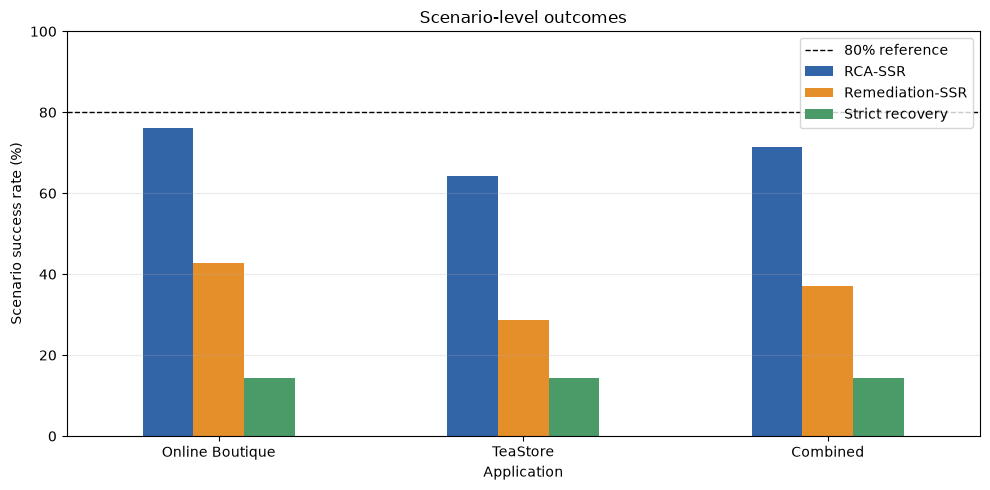

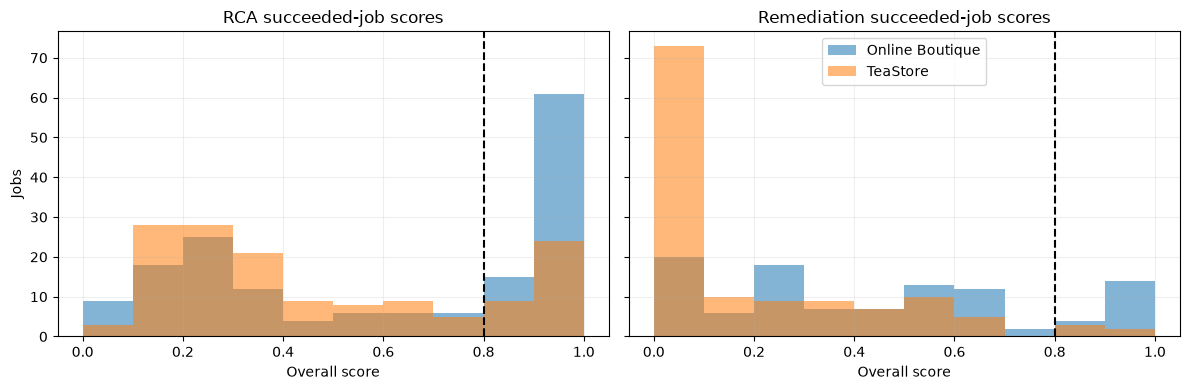

In [8]:
plot_rows = []
for app, g in list(runs.groupby('application')) + [('Combined', runs)]:
    plot_rows.append({'Application': app, 'RCA-SSR': 100*g.rca_score_success.mean(),
        'Remediation-SSR': 100*g.remediation_score_success.mean(),
        'Strict recovery': 100*g.strict_recovery_success.mean()})
plot_df = pd.DataFrame(plot_rows).set_index('Application')
ax = plot_df.plot(kind='bar', figsize=(10,5), color=['#3264a8','#e58f2a','#4b9b69'])
ax.axhline(80, color='black', linestyle='--', linewidth=1, label='80% reference')
ax.set_ylabel('Scenario success rate (%)'); ax.set_ylim(0,100); ax.set_title('Scenario-level outcomes')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=.25); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
for ax, kind, title in zip(axes, ['rca','remediation'], ['RCA succeeded-job scores','Remediation succeeded-job scores']):
    for app, values in scored[scored.kind.eq(kind)].groupby('application').overall_score:
        ax.hist(values, bins=np.linspace(0,1,11), alpha=.55, label=app)
    ax.axvline(THRESHOLD, color='black', linestyle='--'); ax.set_title(title); ax.set_xlabel('Overall score'); ax.grid(alpha=.2)
axes[0].set_ylabel('Jobs'); axes[1].legend(); plt.tight_layout(); plt.show()

## 8. Reporting guidance and limitations

- Report **25/35 (71.4%) RCA-SSR** and **13/35 (37.1%) Remediation-SSR** as the score-threshold results for completed runs. Include the application-specific rates and Wilson intervals shown above.
- Do not confuse score-based Remediation-SSR with strict recovery. A high rubric score does not guarantee metric recovery or absence of a penalty.
- TeaStore has materially lower execution coverage than Online Boutique; always publish completed-run denominators beside rates.
- Job-level means describe output quality but are not independent observations. Use scenario-level SSR for headline claims.
- Results represent one execution per scenario. Confidence intervals quantify binomial uncertainty, not variation across cluster repetitions.
- The node-memory scenarios failed before injection because the archived chaos value used an invalid percentage unit. They should be treated as evaluation failures until rerun with the corrected explicit memory unit.
- Several completed runs produced no remediation. They remain remediation failures because the metric is end-to-end.
- Near-perfect technical-feasibility scores alongside much lower correctness and recovery rates indicate that action selection and evidence alignment—not command construction—are the primary weaknesses.